### 1. Imports and Reproducibility

In [38]:
import random
import numpy as np
import pandas as pd
import torch

# Set random seeds
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.13.0+cpu
Device: cpu


### 2. Load Dataset Metadata

In [39]:
from pathlib import Path
import pandas as pd

# Define metadata path
METADATA_DIR = Path("../data/metadata")

# Load dataset splits
train_df = pd.read_csv(METADATA_DIR / "train.csv")
val_df = pd.read_csv(METADATA_DIR / "validation.csv")
test_df = pd.read_csv(METADATA_DIR / "test.csv")

print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))

Training set: 39264
Validation set: 8414
Test set: 8414


### 3. Verify Dataset Splits

In [40]:
# Check class distribution

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print(df["label"].value_counts())

    


Training
label
uncracked    33325
cracked       5939
Name: count, dtype: int64

Validation
label
uncracked    7141
cracked      1273
Name: count, dtype: int64

Test
label
uncracked    7142
cracked      1272
Name: count, dtype: int64


In [41]:
# Check metadata columns

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTraining sample:")
print(train_df.head())


Columns:
['image_path', 'surface', 'label', 'class_id']

Training sample:
                                          image_path surface      label  \
0  ../data/raw/sdnet2018/deck/uncrack_dataset/702...    deck  uncracked   
1  ../data/raw/sdnet2018/deck/uncrack_dataset/705...    deck  uncracked   
2  ../data/raw/sdnet2018/wall/uncrack_dataset/707...    wall  uncracked   
3  ../data/raw/sdnet2018/wall/uncrack_dataset/710...    wall  uncracked   
4  ../data/raw/sdnet2018/deck/uncrack_dataset/702...    deck  uncracked   

   class_id  
0         0  
1         0  
2         0  
3         0  
4         0  


In [42]:
print(train_df.columns.tolist())

['image_path', 'surface', 'label', 'class_id']


### 4. Define Image Transformations

In [43]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(
        10,
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transformations
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformation:")
print(train_transform)

print("\nValidation/Test transformation:")
print(eval_transform)

Training transformation:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=bilinear, expand=False, fill=0)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transformation:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 5. Create PyTorch Datasets

In [44]:
from torch.utils.data import Dataset
from PIL import Image

class ConcreteCrackDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        # Load image
        image = Image.open(row["image_path"]).convert("RGB")

        # Get label
        label = torch.tensor(row["class_id"], dtype=torch.long)

        # Apply transformation
        if self.transform:
            image = self.transform(image)

        return image, label

In [45]:
# Create datasets

train_dataset = ConcreteCrackDataset(
    train_df,
    transform=train_transform
)

val_dataset = ConcreteCrackDataset(
    val_df,
    transform=eval_transform
)

test_dataset = ConcreteCrackDataset(
    test_df,
    transform=eval_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Training dataset: 39264
Validation dataset: 8414
Test dataset: 8414


### 6. Inspect Dataset Samples

In [46]:
# Inspect one sample

image_tensor, label = train_dataset[0]

print("Image tensor shape:", image_tensor.shape)
print("Image tensor dtype:", image_tensor.dtype)
print("Label:", label.item())
print("Label type:", label.dtype)

Image tensor shape: torch.Size([3, 224, 224])
Image tensor dtype: torch.float32
Label: 0
Label type: torch.int64


In [47]:
# Inspect multiple samples

for index in [0, 100, 1000, 5000]:
    image_tensor, label = train_dataset[index]
    print(
        f"Index: {index} | "
        f"Shape: {tuple(image_tensor.shape)} | "
        f"Label: {label.item()}"
    )

Index: 0 | Shape: (3, 224, 224) | Label: 0
Index: 100 | Shape: (3, 224, 224) | Label: 0
Index: 1000 | Shape: (3, 224, 224) | Label: 0
Index: 5000 | Shape: (3, 224, 224) | Label: 0


### 7. Create DataLoaders

In [48]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 1227
Validation batches: 263
Test batches: 263


### 8. Inspect a Training Batch

In [49]:
# Load one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


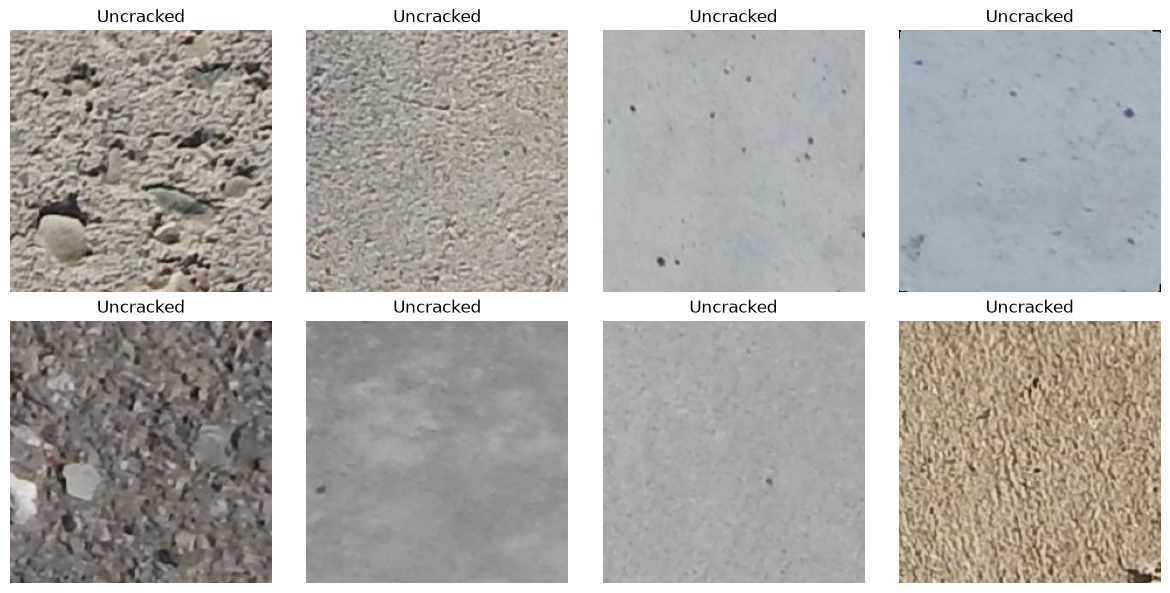

In [60]:
# Reverse normalization for display

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_images = images[:8] * std + mean
display_images = torch.clamp(display_images, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(
    axes.ravel(),
    display_images,
    labels[:8]
):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title("Cracked" if label.item() == 1 else "Uncracked")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 8B. Verify Batch Labels

In [52]:
# Select samples directly from the dataset

sample_indices = [0, 1, 2, 3, 4, 5, 6, 7]

for index in sample_indices:
    _, label = train_dataset[index]
    row = train_dataset.dataframe.iloc[index]

    print(
        f"Index: {index} | "
        f"Label: {row['label']} | "
        f"Class ID: {row['class_id']} | "
        f"Surface: {row['surface']} | "
        f"Path: {row['image_path']}"
    )

Index: 0 | Label: uncracked | Class ID: 0 | Surface: deck | Path: ../data/raw/sdnet2018/deck/uncrack_dataset/7026-126.jpg
Index: 1 | Label: uncracked | Class ID: 0 | Surface: deck | Path: ../data/raw/sdnet2018/deck/uncrack_dataset/7052-82.jpg
Index: 2 | Label: uncracked | Class ID: 0 | Surface: wall | Path: ../data/raw/sdnet2018/wall/uncrack_dataset/7070-244.jpg
Index: 3 | Label: uncracked | Class ID: 0 | Surface: wall | Path: ../data/raw/sdnet2018/wall/uncrack_dataset/7103-191.jpg
Index: 4 | Label: uncracked | Class ID: 0 | Surface: deck | Path: ../data/raw/sdnet2018/deck/uncrack_dataset/7029-130.jpg
Index: 5 | Label: uncracked | Class ID: 0 | Surface: pavement | Path: ../data/raw/sdnet2018/pavement/uncrack_dataset/013-73.jpg
Index: 6 | Label: uncracked | Class ID: 0 | Surface: pavement | Path: ../data/raw/sdnet2018/pavement/uncrack_dataset/080-161.jpg
Index: 7 | Label: uncracked | Class ID: 0 | Surface: wall | Path: ../data/raw/sdnet2018/wall/uncrack_dataset/7101-66.jpg


In [53]:
# Inspect a batch with source information

for i in range(8):
    image_tensor, label = train_loader.dataset[
        i
    ]

    row = train_dataset.dataframe.iloc[i]

    print(
        f"Index: {i} | "
        f"Label: {label.item()} | "
        f"Surface: {row['surface']} | "
        f"Path: {row['image_path']}"
    )

Index: 0 | Label: 0 | Surface: deck | Path: ../data/raw/sdnet2018/deck/uncrack_dataset/7026-126.jpg
Index: 1 | Label: 0 | Surface: deck | Path: ../data/raw/sdnet2018/deck/uncrack_dataset/7052-82.jpg
Index: 2 | Label: 0 | Surface: wall | Path: ../data/raw/sdnet2018/wall/uncrack_dataset/7070-244.jpg
Index: 3 | Label: 0 | Surface: wall | Path: ../data/raw/sdnet2018/wall/uncrack_dataset/7103-191.jpg
Index: 4 | Label: 0 | Surface: deck | Path: ../data/raw/sdnet2018/deck/uncrack_dataset/7029-130.jpg
Index: 5 | Label: 0 | Surface: pavement | Path: ../data/raw/sdnet2018/pavement/uncrack_dataset/013-73.jpg
Index: 6 | Label: 0 | Surface: pavement | Path: ../data/raw/sdnet2018/pavement/uncrack_dataset/080-161.jpg
Index: 7 | Label: 0 | Surface: wall | Path: ../data/raw/sdnet2018/wall/uncrack_dataset/7101-66.jpg


In [54]:
# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transformations
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

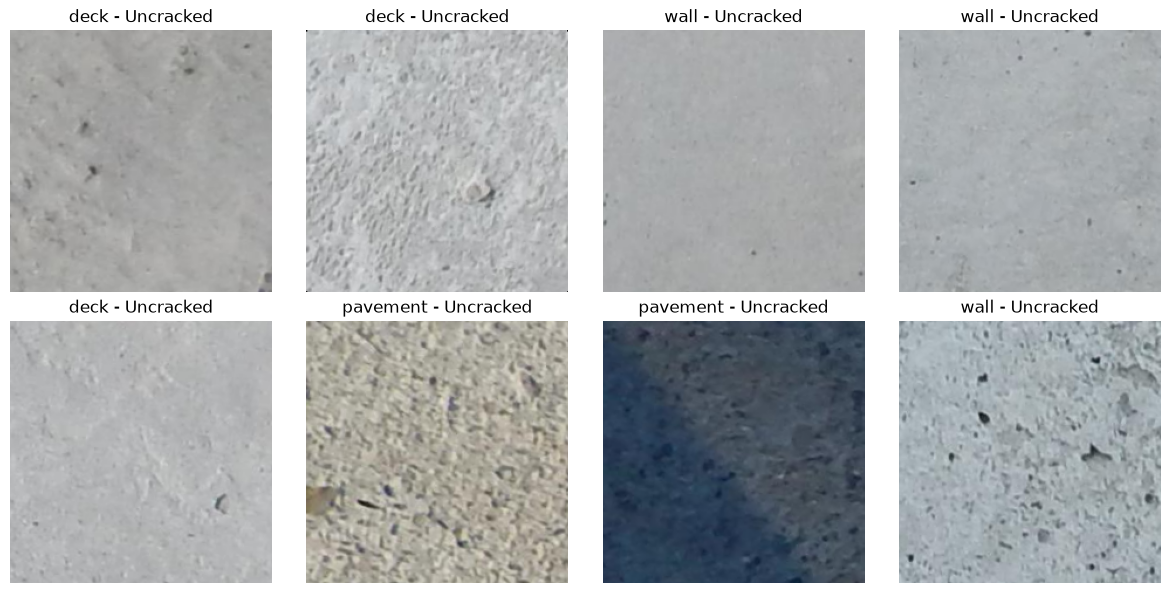

In [55]:
# Display the same dataset samples

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, index in zip(axes.ravel(), sample_indices):
    image_tensor, label = train_dataset[index]
    
    # Reverse normalization
    image = image_tensor * std + mean
    image = torch.clamp(image, 0, 1)
    
    row = train_dataset.dataframe.iloc[index]
    
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(
        f"{row['surface']} - "
        f"{'Cracked' if label.item() == 1 else 'Uncracked'}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [61]:
# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transformations
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [62]:
# Recreate training dataset

train_dataset = ConcreteCrackDataset(
    train_df,
    transform=train_transform
)

print("Training dataset:", len(train_dataset))

Training dataset: 39264


### 8. Inspect a Training Batch — Updated Augmentation

In [63]:
# Load one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


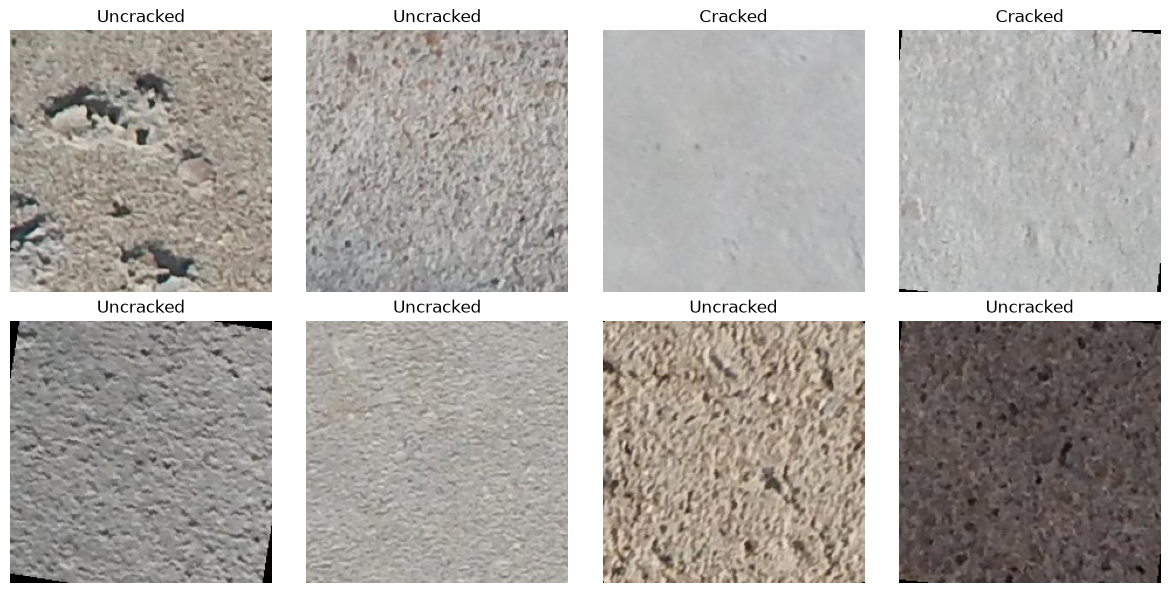

In [64]:
# Reverse normalization for display

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_images = images[:8] * std + mean
display_images = torch.clamp(display_images, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(
    axes.ravel(),
    display_images,
    labels[:8]
):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title("Cracked" if label.item() == 1 else "Uncracked")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# Recreate training DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Training batches:", len(train_loader))

Training batches: 1227


### 9. Define Baseline CNN Architecture

In [65]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### 10. Initialize and Test the Baseline CNN

In [66]:
# Set device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Initialize model
model = BaselineCNN().to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


### 10.1 Test the Baseline CNN

In [67]:
# Test model with one batch

images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 1])


### 11. Define Loss Function and Optimizer

In [68]:
# Calculate class weight

num_uncracked = (train_df["class_id"] == 0).sum()
num_cracked = (train_df["class_id"] == 1).sum()

pos_weight = num_uncracked / num_cracked

print("Uncracked images:", num_uncracked)
print("Cracked images:", num_cracked)
print("Positive class weight:", pos_weight)

Uncracked images: 33325
Cracked images: 5939
Positive class weight: 5.61121400909244


In [69]:
# Define loss function
pos_weight_tensor = torch.tensor(
    [pos_weight],
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

# Define optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### 12. Baseline Model Readiness Check

In [75]:
# Check model and training configuration

print("Model:", model.__class__.__name__)
print("Device:", device)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Batch size:", BATCH_SIZE)
print("Positive class weight:", round(pos_weight, 4))
print("Learning rate:", optimizer.param_groups[0]["lr"])

Model: BaselineCNN
Device: cpu
Training images: 39264
Validation images: 8414
Test images: 8414
Batch size: 32
Positive class weight: 5.6112
Learning rate: 0.001


### 13. Save Baseline Configuration

In [77]:
import json

config = {
    "model": "BaselineCNN",
    "input_size": [224, 224],
    "input_channels": 3,
    "batch_size": BATCH_SIZE,
    "learning_rate": 0.001,
    "loss_function": "BCEWithLogitsLoss",
    "positive_class_weight": float(pos_weight),
    "optimizer": "Adam",
    "seed": SEED,
    "classes": {
        "0": "uncracked",
        "1": "cracked"
    }
}

config_path = Path("../results/metrics/baseline_config.json")
config_path.parent.mkdir(parents=True, exist_ok=True)

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Configuration saved to:", config_path)

Configuration saved to: ..\results\metrics\baseline_config.json


## 14. Baseline Notebook Summary

This notebook established the baseline convolutional neural network (CNN) pipeline for the SDNET2018 concrete crack classification task. The dataset was verified and divided into training, validation and test sets containing 39,264, 8,414 and 8,414 images, respectively. Image transformations were defined to resize the images to 224 × 224 pixels, apply data augmentation to the training set, convert images to tensors and normalize the input values.

A PyTorch dataset and DataLoader structure was established for efficient model training. The baseline CNN architecture was defined using three convolutional feature-extraction blocks followed by adaptive average pooling and a binary classification layer. Because the dataset contains substantially more uncracked than cracked images, a positive-class weight was incorporated into the binary cross-entropy loss function. The Adam optimizer was selected with a learning rate of 0.001.

The baseline model has been initialized and verified for compatibility with the prepared image batches. The model configuration has also been saved for reproducibility. Actual model training and subsequent performance evaluation are presented in the following notebooks.